In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words as n2
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit
import sys
import scipy
import rasterio
from scipy.interpolate import interp2d
from scipy.integrate import quad
from scipy.stats import multivariate_normal
from src2.country_choice import country_select
from src2.shapecheck import shapecheck as sc
from src2.get_nside import get_nside
from src2.FDrule import FDrule
sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

In [2]:
selval,path,path2=country_select()

Select 5k country: Russia
15508 Tx in total


In [3]:
nside=get_nside()

Enter nside value:128


## read data from 5k country

In [4]:
usa_data=pd.read_csv(path)
usa_data=usa_data.dropna()

In [5]:
train_lon=usa_data['Longitude in degrees'].to_numpy()
train_lat=usa_data['Latitude in degrees'].to_numpy()
power=usa_data['EIRP'].to_numpy()
frequency=usa_data['Frequency(MHz)'].to_numpy()

## Remove zero power entries from database

In [6]:
valididx=np.nonzero(power)

In [7]:
train_lon=train_lon[valididx]
train_lat=train_lat[valididx]
power=power[valididx]
frequency=frequency[valididx]
train_pix=hp.ang2pix(nside,train_lon,train_lat,lonlat=True)

In [8]:
finval=selval-len(train_lon) #number of synth data required

In [9]:
power.min() #confirm non zero power data

1

## Visualize country lat lon bivariate distribution

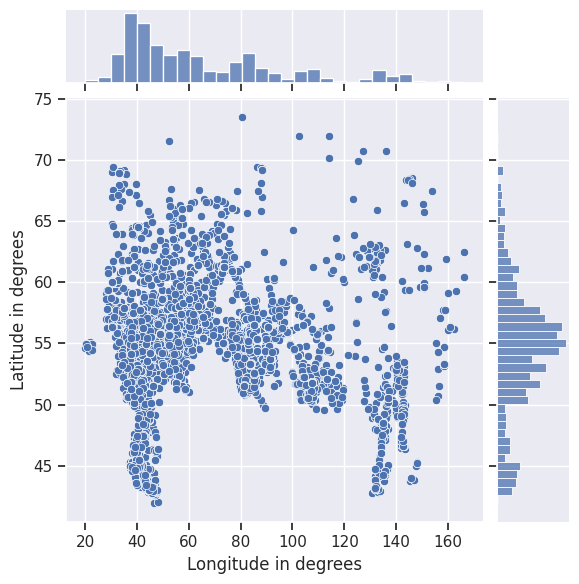

In [10]:
sns.jointplot(x='Longitude in degrees',y='Latitude in degrees',data=usa_data)
plt.show()

## Create 2D histogram and create a smooth PDF using 2D interpolation

In [11]:
data=np.column_stack((train_lon,train_lat))

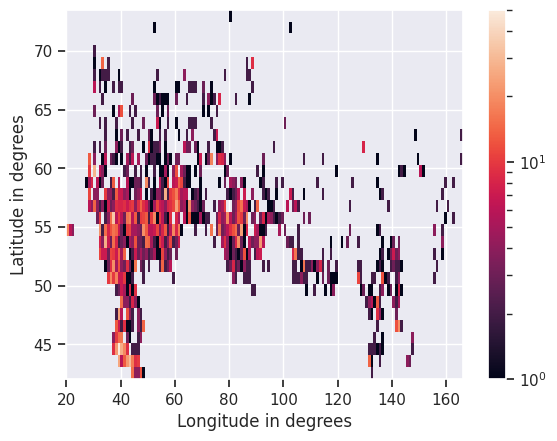

In [12]:
### from mpl_toolkits.axes_grid1 import make_axes_locatable
np.random.seed(42)


x, y = data.T
BIN_COUNT1 = int(max(x)-min(x))
BIN_COUNT2=int(max(y)-min(y))
hist, bins= np.histogramdd(data,bins=(BIN_COUNT1,BIN_COUNT2),density=True)
x_bins=bins[0]
y_bins=bins[1]
x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2

cdf = np.cumsum(hist.flatten())
cdf = cdf / cdf[-1]

# values = np.random.rand(finval)
# value_bins = np.searchsorted(cdf, values)
# x_idx, y_idx = np.unravel_index(value_bins,
#                                 (len(x_bin_midpoints),
#                                  len(y_bin_midpoints)))
# random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
#                                    y_bin_midpoints[y_idx]))
# new_x, new_y = random_from_cdf.T
plt.hist2d(x, y, bins=(BIN_COUNT1, BIN_COUNT2),norm='log')
plt.colorbar()
plt.xlabel('Longitude in degrees')
plt.ylabel('Latitude in degrees')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/2D_hist.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [13]:
hist=hist.reshape(BIN_COUNT1,BIN_COUNT2) # reshape back for interpolation

## Create smooth PDF using RegularGridInterpolator

In [14]:
from scipy.interpolate import RegularGridInterpolator
x1=x_bins[:-1]
y1=y_bins[:-1]
V=hist

fn=RegularGridInterpolator((x1,y1),V,bounds_error=False,fill_value=0)


## Feed every possible pixel within country to interp func and get values

In [15]:
# France shapefile was downloaded from https://gadm.org/download_country.html and rasterized using QGIS
# Open the GeoTIFF file
file_path = path2
src = rasterio.open(file_path)

# Read the raster data as a numpy array
data = src.read(1)  

# Find pixels with non-zero values
non_zero_pixels = np.where(data != 0)

# Get the coordinates of non zero pixels
templat=[]
templon=[]
for y, x in zip(*non_zero_pixels):
    lonval, latval = src.xy(y, x)  # Get the longitude and latitude of the pixel
    templat.append(latval)
    templon.append(lonval)


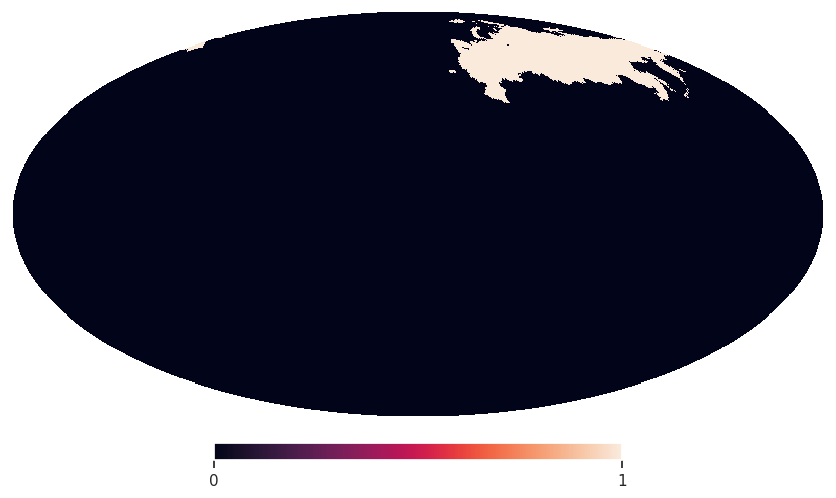

In [16]:
# country raster 
# Making a mask for generated data
temppix=hp.ang2pix(nside,templon,templat,lonlat=True)
template=np.zeros(hp.nside2npix(nside))
for pi in temppix:
    template[pi]+=1
template=np.where(template != 0, 1, 0)
hp.mollview(template,flip='geo',min=0,title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Country_shp.pdf',dpi=600)

In [17]:
pop_pix=np.argwhere(template) # obtain non zero pix aka country pix
pop_pix=np.sort(pop_pix)
allon,allat=hp.pix2ang(nside,pop_pix,lonlat=True)        
allon[allon>180]-=360
allon=allon.reshape(allon.shape[0])
allat=allat.reshape(allat.shape[0])

In [18]:
prob_vals=[] # obtain probabilty values for each pixel of the country (represented by allon and allat)
for i in range(len(allon)):
    a=allon[i]
    b=allat[i]
    prob_vals.append(fn([a,b]))
prob_vals=np.array(prob_vals)
prob_vals=prob_vals.reshape(prob_vals.shape[0]) 

In [19]:
prob_vals=prob_vals/np.sum(prob_vals) # normalize the PDF for generating synth data

In [20]:
prob_pix=hp.ang2pix(nside,allon,allat,lonlat=True)
prob_healpix=np.zeros(hp.nside2npix(nside))
for index,p in enumerate(prob_pix):
    prob_healpix[p]+=(prob_vals[index])

# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)

## Resultant PDF heatmap of every pixel within the country

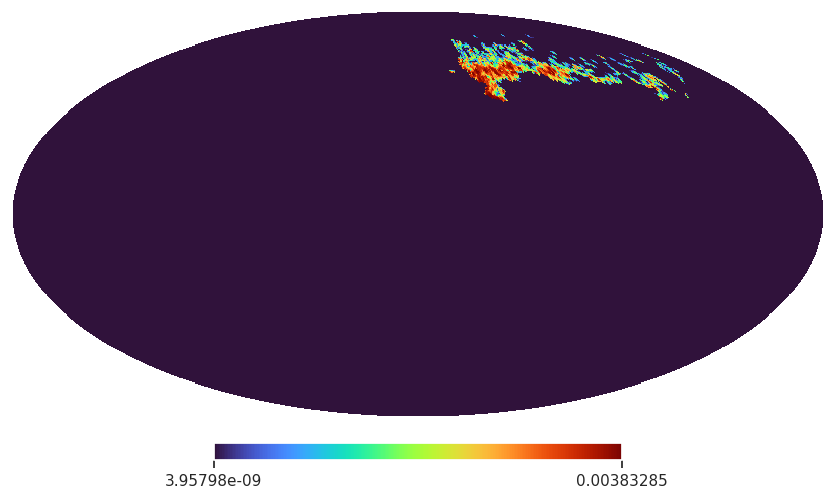

In [21]:
hp.mollview(prob_healpix,flip='geo',cmap='turbo',norm='hist',min=np.min(prob_healpix[np.nonzero(prob_healpix)]),title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Prob_heatmap.pdf',dpi=600)#visualize PDF as a heatmap
plt.show()

In [22]:
pop_pix=pop_pix.reshape(pop_pix.shape[0]) 

## Synthetic Tx locations using the PDF

In [23]:
# Sample from all possible pixels in the country (pop_pix) using prob_vals as probabilty of each pixel
selpix=np.random.choice(pop_pix,size=finval,p=prob_vals) 

In [24]:
latestlon,latestlat=hp.pix2ang(nside,selpix,lonlat=True) # Get lon lat of synth Tx
latestlon[latestlon>180]-=360


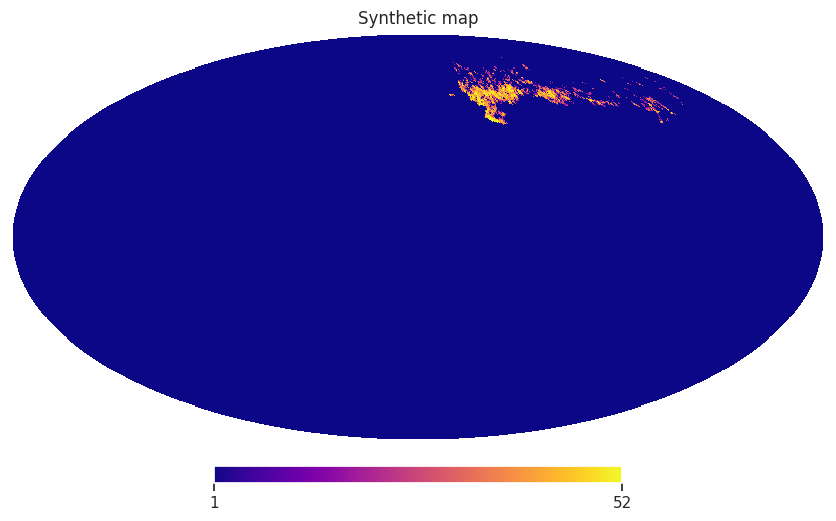

In [25]:
# make number of Tx per pixel map
Tx_new=np.zeros(hp.nside2npix(nside))
for pi in selpix:
    Tx_new[pi]+=1
hp.mollview(Tx_new,flip='geo',cmap='plasma',norm='hist',title='Synthetic map',min=1)
plt.show()

In [26]:
np.sum(Tx_new)-finval # Ensure number of synth Tx is equal to required synth Tx

0.0

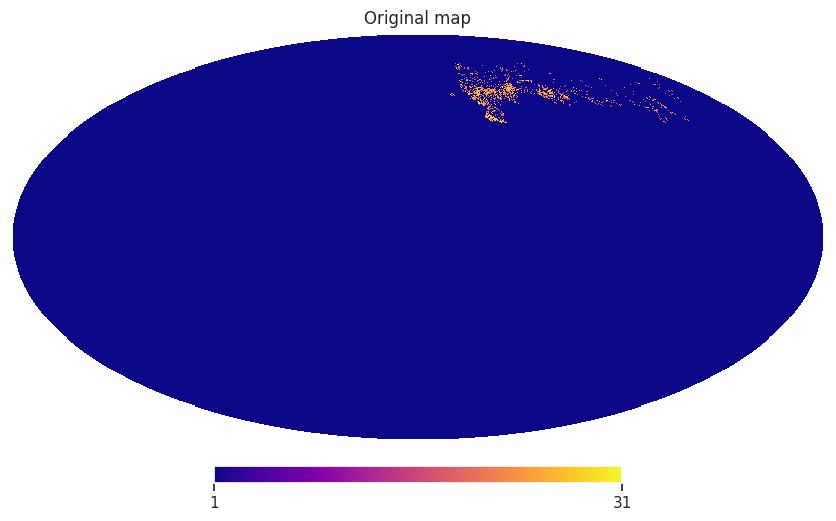

In [27]:
# make number of Tx per pixel map
Tx_num_128=np.zeros(hp.nside2npix(nside))
for pi in train_pix:
    Tx_num_128[pi]+=1
hp.mollview(Tx_num_128,flip='geo',cmap='plasma',norm='hist',title='Original map',min=1)
plt.show()

## power map

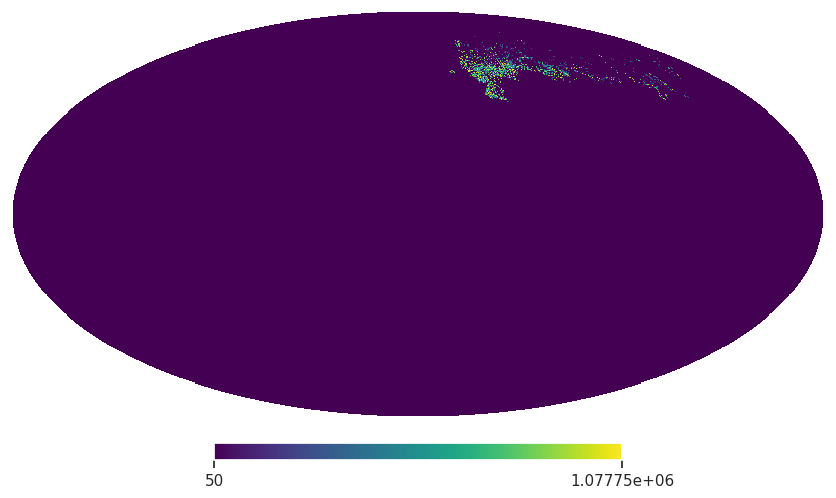

In [28]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(train_pix):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',title='',norm='hist',min=50)
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)


plt.show()

## CDF method for frequencies

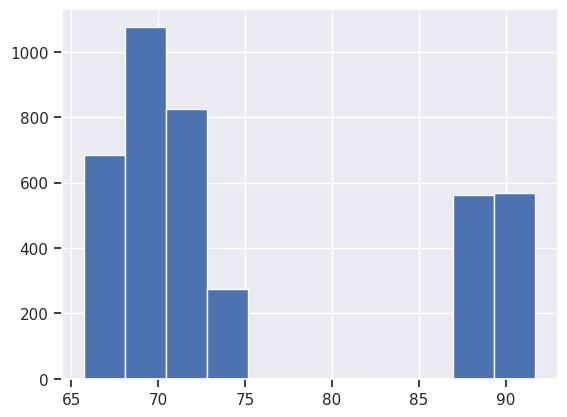

In [29]:
plt.hist(frequency,bins=FDrule(frequency))
plt.show()

In [30]:
data = frequency
# Creating histogram to estimate the CDF
hist1, bins1 = np.histogram(data, bins=FDrule(data), density=True)
cumulative1 = np.cumsum(hist1 * np.diff(bins1))  # Estimating cumulative distribution function (CDF)

In [31]:
new_freq = np.interp(np.random.uniform(0, 1, finval), (cumulative1), bins1[:-1])

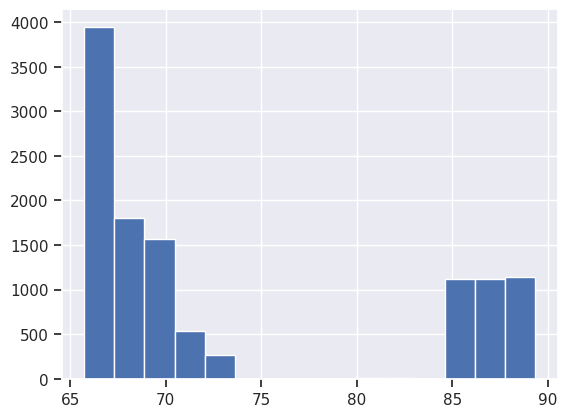

In [32]:
plt.hist(new_freq,bins=FDrule(new_freq))
plt.show()

In [33]:
df=pd.DataFrame({'Freq':power,'pix':train_pix})

In [38]:
median_power_values = df.groupby('pix')['Freq'].median().reset_index()

median_power_df = pd.DataFrame({'Pixel': median_power_values['pix'], 'Median_Power': median_power_values['Freq']})

print(median_power_df)


      Pixel  Median_Power
0      4000         400.0
1      4759          50.0
2      5129         100.0
3      6179       17000.0
4      6213         400.0
...     ...           ...
1230  31184       17000.0
1231  31564         400.0
1232  31565       20000.0
1233  31566         375.0
1234  32580         250.0

[1235 rows x 2 columns]


In [42]:
pixvals=median_power_df['Pixel'].to_numpy()
medpower=median_power_df['Median_Power'].to_numpy()
median_heatmap=np.zeros(hp.nside2npix(nside))
for index,p in enumerate(pixvals):
    median_heatmap[p]=medpower[index]
median_heatmap[median_heatmap==0]=1

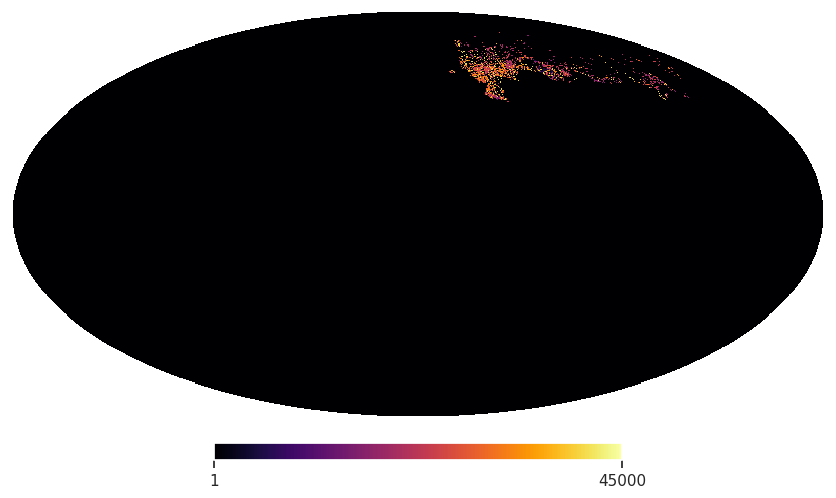

In [44]:
hp.mollview(median_heatmap,flip='geo',norm='log',cmap='inferno',title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Med_Txpows.pdf',dpi=600,bbox_inches='tight')

plt.show()

## CDF method for Tx power

In [37]:
data2 = power
# Creating histogram to estimate the CDF
hist2, bins2 = np.histogram(data2, bins=FDrule(data2), density=True)
cumulative2 = np.cumsum(hist2 * np.diff(bins2))  # Estimating cumulative distribution function (CDF)

In [38]:
new_power= np.interp(np.random.uniform(0, 1, finval), (cumulative2), bins2[:-1])

In [39]:
# plt.hist(power,bins=FDrule(power),label='Original')
# plt.hist(new_power,bins=FDrule(new_power),label='Synth')
# plt.legend()
# plt.show()

## Power per pixel maps

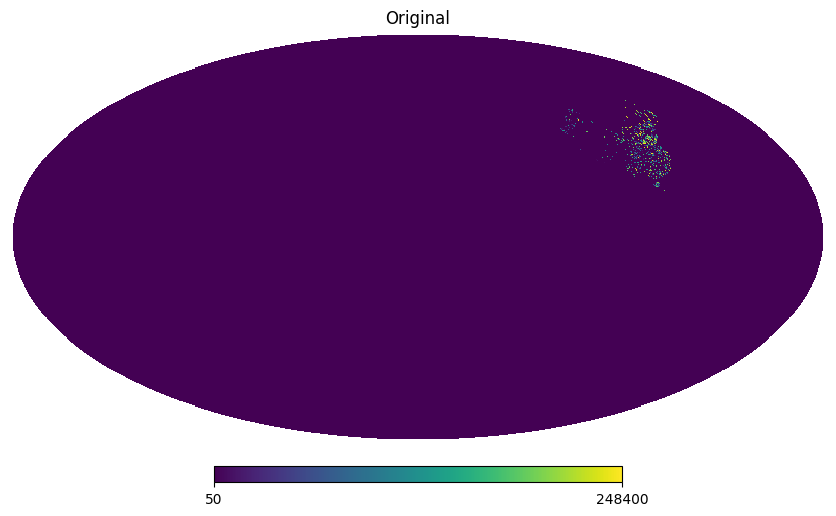

In [40]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(train_pix):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',title='Original',norm='hist',min=50)
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)


plt.show()

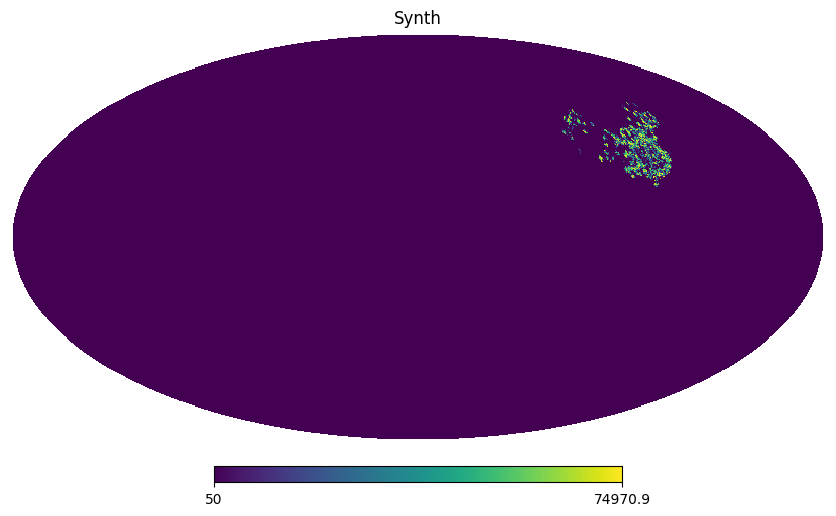

In [41]:
pow_new=np.zeros(hp.nside2npix(128))
for index,p in enumerate(selpix):
    pow_new[p]+=(new_power[index])
hp.mollview(pow_new,flip='geo',cmap='viridis',title='Synth',norm='hist',min=50)
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)


plt.show()

## Create synthetic DB

In [42]:
# daata={'Latitude in degrees':latestlat,'Longitude in degrees':latestlon,'Frequency(MHz)':new_freq,'EIRP':new_power}
# synth_df=pd.DataFrame(daata)
# synth_df.to_csv('/home/pratush/Yogen_STARFIRE/Synth_DB/Brazil_synth.csv')

In [43]:
from num2words import num2words as n2

In [44]:
n2(3.14*((81*110)**2))

'two hundred and forty-nine million, two hundred and seventy-eight thousand, six hundred and thirty-four'

In [45]:
n2( 16376870)

'sixteen million, three hundred and seventy-six thousand, eight hundred and seventy'

## synth db on map

In [46]:
csv_files = '/home/pratush/Yogen_STARFIRE/Synth_DB/Brazil_synth.csv','/home/pratush/Yogen_STARFIRE/Synth_DB/China_synth.csv','/home/pratush/Yogen_STARFIRE/Synth_DB/France_synth.csv','/home/pratush/Yogen_STARFIRE/Synth_DB/Russia_synth.csv','/home/pratush/Yogen_STARFIRE/Synth_DB/Spain_synth.csv'
# --Create an empty dataframe to store the combined data-- #
combined_df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in (csv_files):
    df_temp = pd.read_csv(csv_file)
    combined_df = pd.concat([combined_df, df_temp],ignore_index=True)

lat_128=combined_df['Latitude in degrees'].to_numpy()
lon_128=combined_df['Longitude in degrees'].to_numpy()
power_128=combined_df['EIRP'].to_numpy()
freq_128=combined_df['Frequency(MHz)'].to_numpy()
print(np.shape(lat_128),np.shape(lon_128),np.shape(power_128))
pixel_128=hp.ang2pix(128,lon_128,lat_128,lonlat=True)
    

(26971,) (26971,) (26971,)


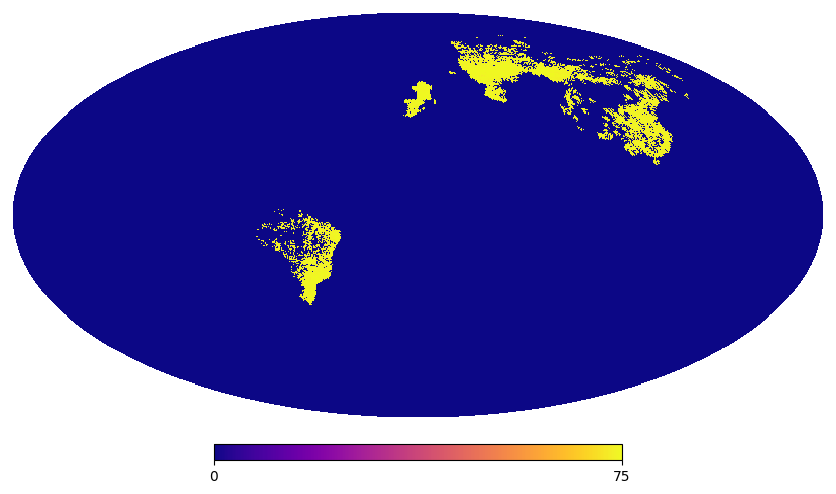

In [47]:
Tx_num_128=np.zeros(hp.nside2npix(128))
for pix in pixel_128:
    Tx_num_128[pix]+=1
hp.mollview(Tx_num_128,flip='geo',min=0,cmap='plasma',norm='hist',title='')
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txnum',dpi=600)
plt.show()

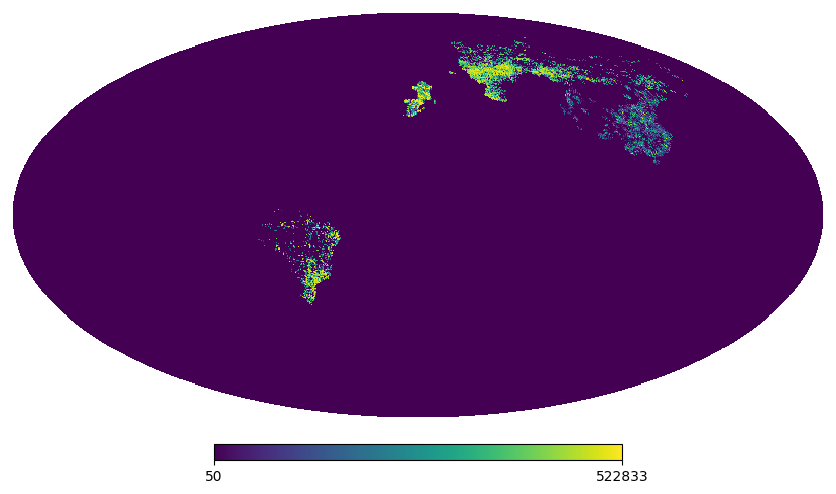

In [48]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pixel_128):
    Tx_pow_128[p]+=(power_128[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',title='',norm='hist',min=50)
# plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)


plt.show()

## interp median power vs lon and lat bins